# NSL-KDD Model Training & Intrusion Detection

This notebook covers preprocessing, model training, evaluation, and a real-time intrusion detection function using the NSL-KDD dataset.

In [ ]:
import pandas as pd
import seaborn as sns #to make graph..high
import matplotlib.pyplot as plt

In [22]:
dataset= pd.read_csv(r"C:\Users\amity\SentinelNet\data\NSL-KDD\KDDTrain+.txt") #load the dataset
dataset.head(10) #check the first 10 rows to get the ides about the dataset

,0,tcp,ftp_data,SF,491,0.1,0.2,0.3,0.4,0.5,...,0.17,0.03,0.17.1,0.00.6,0.00.7,0.00.8,0.05,0.00.9,normal,20
0,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.0,0.00,normal,15
1,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.0,0.00,neptune,19
2,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.0,0.01,normal,21
3,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,normal,21
4,0,tcp,private,REJ,0,0,0,0,0,0,...,0.07,0.07,0.00,0.00,0.00,0.00,1.0,1.00,neptune,21
5,0,tcp,private,S0,0,0,0,0,0,0,...,0.04,0.05,0.00,0.00,1.00,1.00,0.0,0.00,neptune,21
6,0,tcp,private,S0,0,0,0,0,0,0,...,0.06,0.07,0.00,0.00,1.00,1.00,0.0,0.00,neptune,21
7,0,tcp,remote_job,S0,0,0,0,0,0,0,...,0.09,0.05,0.00,0.00,1.00,1.00,0.0,0.00,neptune,21
8,0,tcp,private,S0,0,0,0,0,0,0,...,0.05,0.06,0.00,0.00,1.00,1.00,0.0,0.00,neptune,21
9,0,tcp,private,REJ,0,0,0,0,0,0,...,0.05,0.07,0.00,0.00,0.00,0.00,1.0,1.00,neptune,21


In [ ]:
#Now check the no of rows and columns in the dataset
dataset.shape

(125972, 43)

In [30]:
#now check the null value in  the 10  row.. if null value  then true else false
dataset.isnull()

,0,tcp,ftp_data,SF,491,0.1,0.2,0.3,0.4,0.5,...,0.17,0.03,0.17.1,0.00.6,0.00.7,0.00.8,0.05,0.00.9,normal,20
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125967,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
125968,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
125969,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
125970,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
#to find the number of null values in the 10 columns an done more .sum meansd in oveall dataset 
dataset.isnull().sum()

0           0
tcp         0
ftp_data    0
SF          0
491         0
0.1         0
0.2         0
0.3         0
0.4         0
0.5         0
0.6         0
0.7         0
0.8         0
0.9         0
0.10        0
0.11        0
0.12        0
0.13        0
0.14        0
0.15        0
0.16        0
0.18        0
2           0
2.1         0
0.00        0
0.00.1      0
0.00.2      0
0.00.3      0
1.00        0
0.00.4      0
0.00.5      0
150         0
25          0
0.17        0
0.03        0
0.17.1      0
0.00.6      0
0.00.7      0
0.00.8      0
0.05        0
0.00.9      0
normal      0
20          0
dtype: int64

In [ ]:
#total no of null value  divide by totsal no of row and col*100 to get in percentage
dataset.isnull().sum().sum()/(dataset.shape[0]*dataset.shape[1])*100

np.float64(0.0)

In [ ]:
#percentage null values..shape[0] is no. of rows ...that is to find the percentage of null value in the each column
(dataset.isnull().sum() / dataset.shape[0]) * 100

0           0.0
tcp         0.0
ftp_data    0.0
SF          0.0
491         0.0
0.1         0.0
0.2         0.0
0.3         0.0
0.4         0.0
0.5         0.0
0.6         0.0
0.7         0.0
0.8         0.0
0.9         0.0
0.10        0.0
0.11        0.0
0.12        0.0
0.13        0.0
0.14        0.0
0.15        0.0
0.16        0.0
0.18        0.0
2           0.0
2.1         0.0
0.00        0.0
0.00.1      0.0
0.00.2      0.0
0.00.3      0.0
1.00        0.0
0.00.4      0.0
0.00.5      0.0
150         0.0
25          0.0
0.17        0.0
0.03        0.0
0.17.1      0.0
0.00.6      0.0
0.00.7      0.0
0.00.8      0.0
0.05        0.0
0.00.9      0.0
normal      0.0
20          0.0
dtype: float64

In [ ]:
#total no. of not null values
dataset.notnull().sum().sum()

np.int64(5416796)

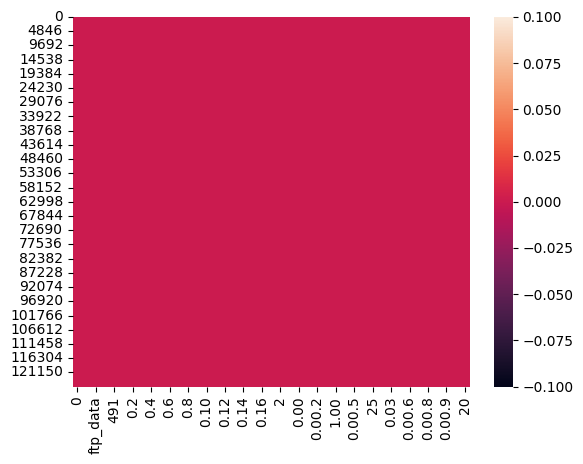

In [ ]:
#true=missing mtlb toward 1 else toward 0
sns.heatmap(dataset.isnull())
plt.show()